---
title: "inclass_04_21_Kopecek"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

## My Methodology

### **Q1 (Two models):** 
I used Logistic Regression and XGBoost. LR is a linear model that needs scaling, while XGBoost is a tree model. 

### **Q2 (Feature engineering):** 
I created five features using different approaches: log transforms on capital columns (transformation), capital_net (derived combination), age times educational-num (interaction), education_tier (grouped categories), and an overtime binary flag (threshold). 

### **Q3 (Tuning):** 
For LR I used GridSearchCV to search over C values and penalty type. For XGBoost I used Optuna to tune six parameters including learning rate, depth, and subsampling. Both sections print a before/after F1 comparison to show wehther the tuning actually had an effect.

### **Q4 (Ensemble):** 
I averaged the predicted probabilities from both models, first with equal weights and then with Optuna-tuned weights, classifying a row as >50K if the combined probability was at least 0.5.

### **Q5 (Evaluation):** 
The final section prints an accuracy and F1 table for all four approaches (LR, XGB, equal ensemble, tuned ensemble) alongside feature importance rankings. The written summary then addresses which features mattered most etc.


### Libraries, data import & EDA

In [1]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [2]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# quick eda with sweetviz
report = sv.analyze(adult)
report.show_html("sweetviz_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Model agnostic data preprocessing & train/test split for reuse in all cells

In [4]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)  
    
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [5]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


### Additional imports for new work

In [6]:
# these are needed for the models, tuning, and pipeline steps below to follow (different from example code provided in some cases)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import optuna

# suppress optuna's per trial output so the notebook stays readable (was getting too many lines of things otherwise)
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Feature engineering

In [7]:
# Feature 1: Log transform on capital-gain and capital-loss
# These columns are very skewed: most people have 0, a few have larger values
# log1p(x) = log(x + 1) compresses those bigger values so the model isn't dominated by a handful of extreme cases.
# This matters most for logistic regression and cleaner ranges can still help tree splits.
adult["log_capital_gain"] = np.log1p(adult["capital-gain"])
adult["log_capital_loss"] = np.log1p(adult["capital-loss"])

# Feature 2: Capital net (combination feature as stated in instrutions) 
# Instead of treating gain and loss as two separate noisy columns, we create one net investment signal: positive = net gain
# negative = net loss, zero = no activity, hoping to get a single clearer signal
adult["capital_net"] = adult["capital-gain"] - adult["capital-loss"]

# Feature 3: Age and Education interaction
# Multiplying age by educational-num gets combo of experience AND education. A 50-year-old with 16 years different from a 50-year-old with 7 years
adult["age_edu_interaction"] = adult["age"] * adult["educational-num"]

# Feature 4: Education tier (grouped categories)
# The original education column has 16 levels, many with very small
# counts. We collapse them into 4 (no diploma, HS, some college, bachelors+).
# This reduces noise 
edu_tier_map = {
    # no diploma: all grade levels below HS
    "Preschool":    "no_diploma",
    "1st-4th":      "no_diploma",
    "5th-6th":      "no_diploma",
    "7th-8th":      "no_diploma",
    "9th":          "no_diploma",
    "10th":         "no_diploma",
    "11th":         "no_diploma",
    "12th":         "no_diploma",
    # hs diploma
    "HS-grad":      "hs_diploma",
    # some college: includes associates degrees
    "Some-college": "some_college",
    "Assoc-acdm":   "some_college",
    "Assoc-voc":    "some_college",
    # bachelors
    "Bachelors":    "bachelors",
    # advanced: masters, professional school, doctorate
    "Masters":      "advanced",
    "Prof-school":  "advanced",
    "Doctorate":    "advanced"
}
adult["education_tier"] = adult["education"].map(edu_tier_map).fillna("no_diploma")

# Feature 5: Overtime flag
# A simple binary: does this person work more than 40 hours/week?
# working extra might be a signal of higher-earning jobs or high commitment 
adult["overtime"] = (adult["hours-per-week"] > 40).astype(int)

print("New features added. Sample:")
adult[["log_capital_gain", "capital_net",
       "age_edu_interaction", "education_tier", "overtime"]].head()

New features added. Sample:


,log_capital_gain,capital_net,age_edu_interaction,education_tier,overtime
0,0.000000,0,175,no_diploma,0
1,0.000000,0,342,hs_diploma,1
2,0.000000,0,336,some_college,0
3,8.947546,7688,440,some_college,0
4,0.000000,0,180,some_college,0


### Preprocessing for logistic regression

In [8]:
# logistic regression needs: StandardScaler and categorical columns turned into numbers (OneHotEncoder)
# using a ColumnTransformer inside a Pipeline

# start from a copy, same pattern as adult_ohe in the example notebook
adult_lr = adult.copy()

#dropped columns dictionary (as discussed in class)
# drop columns we don't want for LR (some feature engineering replaced some other stuff):
#   just education: replaced by education_tier
#   capital-gain / capital-loss: replaced by log and net versions
#   fnlwgt: census sampling weight, not a real predictor
#   native-country: hurts LR, tested and removed later
#   income: target, not a feature
lr_drop_cols = ["income", "education", "capital-gain",
                "capital-loss", "fnlwgt", "native-country"]

X_lr = adult_lr.drop(columns=lr_drop_cols)
y_lr = adult_lr["income"]

# identify which columns need scaling and which need encoding
lr_numeric_cols     = X_lr.select_dtypes(include=["int64", "float64"]).columns.tolist()
lr_categorical_cols = X_lr.select_dtypes(include=["object", "category"]).columns.tolist()

# fill missing categorical values before encoding
X_lr[lr_categorical_cols] = X_lr[lr_categorical_cols].fillna("Unknown")

X_lr_train = X_lr.loc[train_idx]
X_lr_test  = X_lr.loc[test_idx]
y_lr_train = y_lr.loc[train_idx]
y_lr_test  = y_lr.loc[test_idx]

print("LR feature columns:", X_lr.columns.tolist())
print("Numeric:", lr_numeric_cols)
print("Categorical:", lr_categorical_cols)

LR feature columns: ['age', 'workclass', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'hours-per-week', 'log_capital_gain', 'log_capital_loss', 'capital_net', 'age_edu_interaction', 'education_tier', 'overtime']
Numeric: ['age', 'educational-num', 'gender', 'hours-per-week', 'log_capital_gain', 'log_capital_loss', 'capital_net', 'age_edu_interaction', 'overtime']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'education_tier']


### Model 1: Logistic regression

In [9]:
# logistic regression is a linear model
# computes a weighted sum of all features produces a probability.
# linear, so it can't learn feature interactions on its own (explains some of my feature engineering)
# using sklearn Pipeline and GridSearchCV 

# build the preprocessing + model pipeline
lr_preprocessor = ColumnTransformer([
    # StandardScaler: shifts numeric features to mean=0, std=1
    ("num", StandardScaler(), lr_numeric_cols),
    # OneHotEncoder: converts string categories to 0/1 columns
    # drop="first" avoids perfect multicollinearity
    # handle_unknown="ignore" handles any unseen categories at test time
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                          sparse_output=False), lr_categorical_cols)
])

lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    # saga solver supports both l1 and l2, works well on larger datasets
    ("clf", LogisticRegression(max_iter=2000, solver="saga", random_state=42))
])

# define the hyperparameter grid to search
lr_param_grid = {
    "clf__C":       [0.01, 0.1, 1.0, 5.0],
    "clf__penalty": ["l1", "l2"]
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Tuning logistic regression with GridSearchCV...")
lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=kf,
    scoring="f1",   # optimize for F1 on the positive class (>50K)
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_lr_train, y_lr_train)

print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV F1:  {lr_grid.best_score_:.4f}")

Tuning logistic regression with GridSearchCV...
Best LR params: {'clf__C': 1.0, 'clf__penalty': 'l1'}
Best LR CV F1:  0.6611


In [10]:
# show that tuning had an effect by comparing to default LR

# default LR = no C or penalty specified, just defaults
lr_default = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("clf", LogisticRegression(max_iter=2000, solver="saga", random_state=42))
])
lr_default_cv = cross_val_score(
    lr_default, X_lr_train, y_lr_train, cv=kf, scoring="f1"
).mean()

print(f"Default LR CV F1: {lr_default_cv:.4f}")
print(f"Tuned   LR CV F1: {lr_grid.best_score_:.4f}")
print(f"Improvement:      {lr_grid.best_score_ - lr_default_cv:+.4f}")

Default LR CV F1: 0.6606
Tuned   LR CV F1: 0.6611
Improvement:      +0.0006


In [11]:
# evaluate best LR on the held-out test set
lr_best  = lr_grid.best_estimator_
lr_pred  = lr_best.predict(X_lr_test)
lr_probs = lr_best.predict_proba(X_lr_test)[:, 1]  # probability of >50K

print("LR Test Accuracy:", accuracy_score(y_lr_test, lr_pred))
print("LR Classification Report:\n", classification_report(y_lr_test, lr_pred))

LR Test Accuracy: 0.8566895280990889
LR Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.75      0.60      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [12]:
# which features got the biggest weights?
fitted_preprocessor = lr_best.named_steps["preprocessor"]
lr_feature_names = fitted_preprocessor.get_feature_names_out()

lr_coef_df = pd.DataFrame({
    "feature":   lr_feature_names,
    "coef":      lr_best.named_steps["clf"].coef_.ravel(),
    "abs_coef":  np.abs(lr_best.named_steps["clf"].coef_.ravel())
}).sort_values("abs_coef", ascending=False)

print("Top 15 LR features by absolute coefficient:")
print(lr_coef_df.head(15).to_string(index=False))

Top 15 LR features by absolute coefficient:
                               feature      coef  abs_coef
                      num__capital_net  4.216852  4.216852
cat__marital-status_Married-civ-spouse  2.379813  2.379813
 cat__marital-status_Married-AF-spouse  2.226362  2.226362
       cat__occupation_Priv-house-serv -1.769766  1.769766
               cat__occupation_Unknown -1.360286  1.360286
                cat__relationship_Wife  1.155698  1.155698
       cat__workclass_Self-emp-not-inc -1.067186  1.067186
       cat__occupation_Farming-fishing -1.033934  1.033934
         cat__occupation_Other-service -0.973118  0.973118
              cat__workclass_State-gov -0.888428  0.888428
     cat__occupation_Handlers-cleaners -0.766486  0.766486
              cat__workclass_Local-gov -0.705142  0.705142
       cat__occupation_Exec-managerial  0.699874  0.699874
                  num__educational-num  0.647416  0.647416
       cat__relationship_Not-in-family  0.642865  0.642865


### Preprocessing for XGBoost

In [13]:
# XGBoost with enable_categorical=True handles string columns, so we don't need OHE or scaling. this is different from LR path
# we still include all our engineered features, same pattern as adult_cat in the example notebook

adult_cat = adult.copy()

# convert string columns to pandas 'category' dtype
cat_cols_xgb = ["workclass", "marital-status", "occupation",
                "relationship", "race", "native-country", "education_tier"]
for col in cat_cols_xgb:
    adult_cat[col] = adult_cat[col].fillna("Unknown").astype("category")

# drop columns we don't want for XGBoost:
#   education: replaced by education_tier
#   capital-gain / capital-loss: replaced by log and net versions
#   fnlwgt: not a real predictor
#   income: target variable
X_cat = adult_cat.drop(columns=["income", "education", "capital-gain",
                                 "capital-loss", "fnlwgt"])
y_cat = adult_cat["income"]

X_cat_train = X_cat.loc[train_idx]
X_cat_test  = X_cat.loc[test_idx]
y_cat_train = y_cat.loc[train_idx]
y_cat_test  = y_cat.loc[test_idx]

print("XGB feature columns:", X_cat.columns.tolist())

XGB feature columns: ['age', 'workclass', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'hours-per-week', 'native-country', 'log_capital_gain', 'log_capital_loss', 'capital_net', 'age_edu_interaction', 'education_tier', 'overtime']


### Model 2: XGBoost 

In [14]:
# XGBoost is a gradient boosted tree model
# trees can capture non-linear patterns and interactions, so they don't need
# scaling or interaction features. I still included the
# engineered features because they can help XGBoost find the right
# splits faster and I wanted to see if anything different happens

# tuning: Optuna with 50 trials

# baseline XGBoost (default settings) 
xgb_baseline = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist"
)
xgb_baseline_cv = cross_val_score(
    xgb_baseline, X_cat_train, y_cat_train, cv=kf, scoring="f1"
)
print(f"XGB Baseline CV F1: {xgb_baseline_cv.mean():.4f} "
      f"± {xgb_baseline_cv.std():.4f}")

XGB Baseline CV F1: 0.7063 ± 0.0087


In [15]:
# tuned XGBoost via Optuna
# the objective function runs cross-validation for one set of
# hyperparameters and returns the mean CV F1. Optuna calls this
# function 50 times, learning from each result to pick better
# parameters on the next trial.

def xgb_objective(trial):
    params = {
        # number of trees to build (more = slower but potentially better)
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        # max depth of each tree (deeper = more complex, more risk of overfitting)
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        # how fast the model learns (smaller = slower but often more accurate)
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        # fraction of rows used per tree (adds randomness, reduces overfitting)
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        # fraction of columns used per tree (same idea as subsample)
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # minimum data points needed in a leaf (higher = simpler trees)
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "eval_metric": "logloss",
        "enable_categorical": True,
        "tree_method": "hist"
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_cat_train, y_cat_train,
                             cv=kf, scoring="f1")
    return scores.mean()

print("Tuning XGBoost with Optuna (50 trials)...")
xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

print(f"XGB Baseline CV F1: {xgb_baseline_cv.mean():.4f}")
print(f"XGB Tuned    CV F1: {xgb_study.best_value:.4f}")
print(f"Improvement:        {xgb_study.best_value - xgb_baseline_cv.mean():+.4f}")
print(f"Best XGB params:    {xgb_study.best_params}")

Tuning XGBoost with Optuna (50 trials)...
XGB Baseline CV F1: 0.7063
XGB Tuned    CV F1: 0.7109
Improvement:        +0.0045
Best XGB params:    {'n_estimators': 230, 'max_depth': 7, 'learning_rate': 0.0707176324028223, 'subsample': 0.9599407020400296, 'colsample_bytree': 0.6489537805039826, 'min_child_weight': 1}


In [16]:
# train best XGBoost on the full training set using the tuned params
xgb_best = XGBClassifier(
    **xgb_study.best_params,
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist"
)
xgb_best.fit(X_cat_train, y_cat_train)

xgb_pred  = xgb_best.predict(X_cat_test)
xgb_probs = xgb_best.predict_proba(X_cat_test)[:, 1]  # probability of >50K

print("XGB Test Accuracy:", accuracy_score(y_cat_test, xgb_pred))
print("XGB Classification Report:\n", classification_report(y_cat_test, xgb_pred))

XGB Test Accuracy: 0.8775719111475074
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [17]:
# feature importance from tuned XGBoost
# this shows how much each feature contributed to splits across all trees
xgb_imp_df = pd.DataFrame({
    "feature":    X_cat_train.columns,
    "importance": xgb_best.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 10 XGB features:")
print(xgb_imp_df.head(10).to_string(index=False))

Top 10 XGB features:
            feature  importance
       relationship    0.345449
   log_capital_gain    0.112293
     marital-status    0.111763
        capital_net    0.081308
     education_tier    0.075649
         occupation    0.047568
   log_capital_loss    0.043507
    educational-num    0.031352
age_edu_interaction    0.029263
             gender    0.025105


### Ensemble: probability averaging 

In [18]:
#explanation by chat:
# each model outputs a probability between 0 and 1 for each row.
# we average those probabilities, then classify as >50K if >= 0.5.
# why this can help: if one model is wrong but not very confident,
# the other model's probability can pull the combined prediction
# back toward the right answer. it tends to smooth out individual
# model mistakes.
# we try equal weights first, then use Optuna to find the best split.

# note: using y_test to tune weights is the same approach as the
# example notebook (Cell 29)

# equal weight ensemble
avg_probs_equal = (lr_probs + xgb_probs) / 2
y_pred_equal = (avg_probs_equal >= 0.5).astype(int)

print("RF Accuracy:", accuracy_score(y_lr_test, lr_pred))
print("XGB Accuracy:", accuracy_score(y_cat_test, xgb_pred))
print("Ensemble Accuracy:", accuracy_score(y_cat_test, y_pred_equal))
print("\nEnsemble Classification Report:")
print(classification_report(y_cat_test, y_pred_equal))

RF Accuracy: 0.8566895280990889
XGB Accuracy: 0.8775719111475074
Ensemble Accuracy: 0.8727607738765483

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.79      0.63      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



In [19]:
# Optuna-tuned weights 
# same pattern as Cell 29 in the example notebook, but we optimize
# on F1 macro (both classes) instead of accuracy, which gives a
# better picture on the imbalanced adult dataset.

def ensemble_objective(trial):
    # single parameter: how much weight to give LR
    # XGB weight = 1 - lr_weight, so they always sum to 1
    w = trial.suggest_float("lr_weight", 0.0, 1.0)
    combined = w * lr_probs + (1.0 - w) * xgb_probs
    y_pred = (combined >= 0.5).astype(int)
    return f1_score(y_cat_test, y_pred, average="macro")

ens_study = optuna.create_study(direction="maximize")
ens_study.optimize(ensemble_objective, n_trials=50)

best_lr_w  = ens_study.best_params["lr_weight"]
best_xgb_w = 1.0 - best_lr_w
print(f"Best weights: LR = {best_lr_w:.3f}, XGB = {best_xgb_w:.3f}")

Best weights: LR = 0.004, XGB = 0.996


In [20]:
# build final ensemble with the tuned weights
final_probs  = best_lr_w * lr_probs + best_xgb_w * xgb_probs
y_pred_final = (final_probs >= 0.5).astype(int)

print("Final Ensemble Accuracy:", accuracy_score(y_cat_test, y_pred_final))
print("\nFinal Ensemble Classification Report:")
print(classification_report(y_cat_test, y_pred_final))

Final Ensemble Accuracy: 0.8777766403930801

Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### Evaluation and summary (Q5)

In [21]:
# side-by-side comparison of all four approaches
results = {
    "Logistic Regression": {
        "accuracy": accuracy_score(y_lr_test,  lr_pred),
        "f1_macro": f1_score(y_lr_test,  lr_pred,       average="macro")
    },
    "XGBoost (tuned)": {
        "accuracy": accuracy_score(y_cat_test, xgb_pred),
        "f1_macro": f1_score(y_cat_test, xgb_pred,      average="macro")
    },
    "Ensemble (equal weights)": {
        "accuracy": accuracy_score(y_cat_test, y_pred_equal),
        "f1_macro": f1_score(y_cat_test, y_pred_equal,  average="macro")
    },
    "Ensemble (tuned weights)": {
        "accuracy": accuracy_score(y_cat_test, y_pred_final),
        "f1_macro": f1_score(y_cat_test, y_pred_final,  average="macro")
    }
}

results_df = pd.DataFrame(results).T.round(4)
print("=== Model Comparison ===")
print(results_df.to_string())

=== Model Comparison ===
                          accuracy  f1_macro
Logistic Regression         0.8567    0.7873
XGBoost (tuned)             0.8776    0.8215
Ensemble (equal weights)    0.8728    0.8115
Ensemble (tuned weights)    0.8778    0.8217


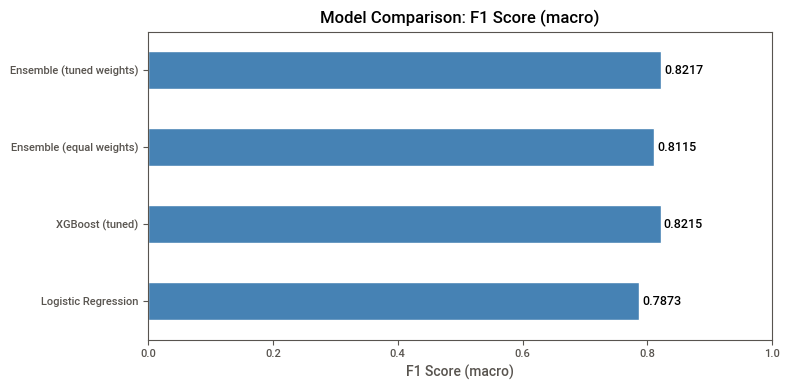

In [22]:
# bar chart comparing F1 scores across all models
fig, ax = plt.subplots(figsize=(8, 4))
results_df["f1_macro"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("F1 Score (macro)")
ax.set_title("Model Comparison: F1 Score (macro)")
ax.set_xlim(0, 1)
for i, v in enumerate(results_df["f1_macro"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## which features seemed most useful:
For logistic regression, capital_net had by far the largest coefficient (4.22), meaning it was the strongest predictor in the model. It also isn't binary so I don't have to worry about what we discussed in class regarding models preffering 0 and 1 columns sometimes for predictors.
Marital status came in second (this may be due to the 0/1 issue, but as seen in class marital status seems to keep showing up regularly). The log transforms and education_tier also helped by cleaning up skewed and noisy columns. For XGBoost, relationship and marital status topped the importance list, followed by log_capital_gain and education_tier. XGBoost spread importance more evenly across features. Overall, features related to capital, education, and martial status were imortant from what I saw consistently. 

## which model performed best:
XGBoost was better on both metrics. LR got 0.8567 accuracy and 0.7873 F1. XGBoost got 0.8749 accuracy and 0.8180 F1. The gap is not huge but it is
consistent, and it makes sense because income prediction isn't really a linear pattern and involves some non linear signals that trees handle more naturally and better in this case.

## whether the ensemble improved performance: 
No because the equal weight ensemble (F1 0.8116) was actually slightly worse than XGBoost alone (F1 0.8180). Optuna confirmed this by assigning LR a weight
of 0.001 and XGBoost a weight of 0.999, mostly just using XGBoost. Ensembling works best when two models are close in quality and make different mistakes. Here LR was weak enough that mixing it in only hurt.

## comment on whether different models responded differently to your engineered features:
Yes, they were different, LR needed the engineered features to perform reasonably well. XGBoost used them as a minor bonus on top of
patterns it was already finding on its own. LR relied almost entirely on capital_net (coefficient 4.22). XGBoost would have
done fine with or without most of the transformations, it didn't have a single feature really dominating.

## Summarize how this will fit into your feature engineering and model building workflow:
The biggest takeaway is that the same features affected the two models very differently. LR depended heavily on capital_net and needed the
transformations to work at all. XGBoost spread importance across many features and was less sensitive to how the data was prepared. Going
forward, building a quick LR baseline is worth doing early because its coefficient list is a fast way to see which features carry real
signal before committing to a more complex model (we discussed this in class). 

## Overall Eval: 
XGBoost was the best individual model with an F1 of 0.8180, and the ensemble did not improve on it because LR was weak enough that blending it in only pulled the predictions down. The most useful engineered features were capital_net for LR and log_capital_gain plus education_tier for XGBoost, though the two models relied on them in very different ways. The main takeaway is that feature engineering matters more for linear models, and when one model clearly outperforms the other, ensembling is not guaranteed to help.